In [1]:
from fh_script import fh_inference
import xarray as xr
from dataloader import open_dataset
import matplotlib.pyplot as plt

In [2]:
gen_path = '/lustre/storeB/project/fou/hi/foccus/malene/run-anemoi-ocean/ppi/external_checkpoint_inference/Inference_res/lr_v2/lr3-5e-04-st200-se42'
data_path = '2024-03-30_24h_18d28_e011_s049990.nc'
data_path2 = '2024-03-31_24h_18d28_e011_s049990.nc'
data_path3 = '2024-04-01_24h_18d28_e011_s049990.nc'
data_path4 = '2024-04-02_24h_18d28_e011_s049990.nc'
data_path5 = '2024-04-03_24h_18d28_e011_s049990.nc'
data_path6 = '2024-04-04_24h_18d28_e011_s049990.nc'
data_path7 = '2024-04-05_24h_18d28_e011_s049990.nc'

In [3]:
lofoten_3003 = open_dataset(f'{gen_path}/{data_path}', region='lofoten').dataset
lofoten_3103 = open_dataset(f'{gen_path}/{data_path2}', region='lofoten').dataset
lofoten_0104 = open_dataset(f'{gen_path}/{data_path3}', region='lofoten').dataset
lofoten_0204 = open_dataset(f'{gen_path}/{data_path4}', region='lofoten').dataset
lofoten_0304 = open_dataset(f'{gen_path}/{data_path5}', region='lofoten').dataset
lofoten_0404 = open_dataset(f'{gen_path}/{data_path6}', region='lofoten').dataset
lofoten_0504 = open_dataset(f'{gen_path}/{data_path7}', region='lofoten').dataset

In [4]:
ds = xr.combine_by_coords([lofoten_3003, lofoten_3103, lofoten_0104, lofoten_0204, lofoten_0304, lofoten_0404, lofoten_0504])

In [5]:
ds_dropped_duplicates = ds.drop_duplicates(dim = ['X', 'Y'])

In [6]:
ds_dropped_duplicates

<xarray.Dataset> Size: 2GB
Dimensions:            (time: 63, X: 747, Y: 805)
Coordinates:
  * X                  (X) float64 6kB 2.488e+05 2.496e+05 ... 8.456e+05
  * Y                  (Y) float64 6kB 1.173e+06 1.174e+06 ... 1.816e+06
  * time               (time) datetime64[ns] 504B 2024-03-30 ... 2024-04-06
Data variables:
    latitude           (time, X, Y) float32 152MB nan nan nan ... nan nan nan
    longitude          (time, X, Y) float32 152MB nan nan nan ... nan nan nan
    salinity_0         (time, X, Y) float32 152MB nan nan nan ... nan nan nan
    temperature_0      (time, X, Y) float32 152MB nan nan nan ... nan nan nan
    u_eastward_0       (time, X, Y) float32 152MB nan nan nan ... nan nan nan
    v_northward_0      (time, X, Y) float32 152MB nan nan nan ... nan nan nan
    h                  (time, X, Y) float32 152MB nan nan nan ... nan nan nan
    sea_mask           (time, X, Y) float32 152MB nan nan nan ... nan nan nan
    f                  (time, X, Y) float32 152MB nan nan nan ... nan nan nan
    river_binary_mask  (time, X, Y) float32 152MB nan nan nan ... nan nan nan

In [7]:
f = ds_dropped_duplicates.f
h = ds_dropped_duplicates.h
f_h = f/h

 ...]

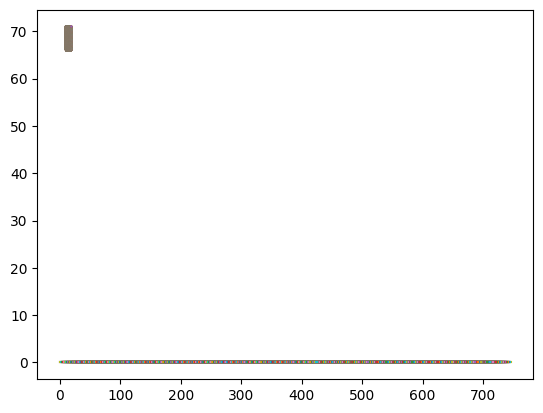

In [8]:
plt.plot(ds_dropped_duplicates.longitude[0,:,:].values, ds_dropped_duplicates.latitude[0,:,:].values, f_h[0,:,:])

Shape U: (8, 747, 805). Shape V ; (8, 747, 805).
f_h has dimensions: (63, 747, 805)


/lustre/storeB/project/fou/hi/foccus/.venv/lib64/python3.11/site-packages/cartopy/mpl/geoaxes.py:1600: UserWarning: The following kwargs were not used by contour: 'color'
  result = super().contour(*args, **kwargs)


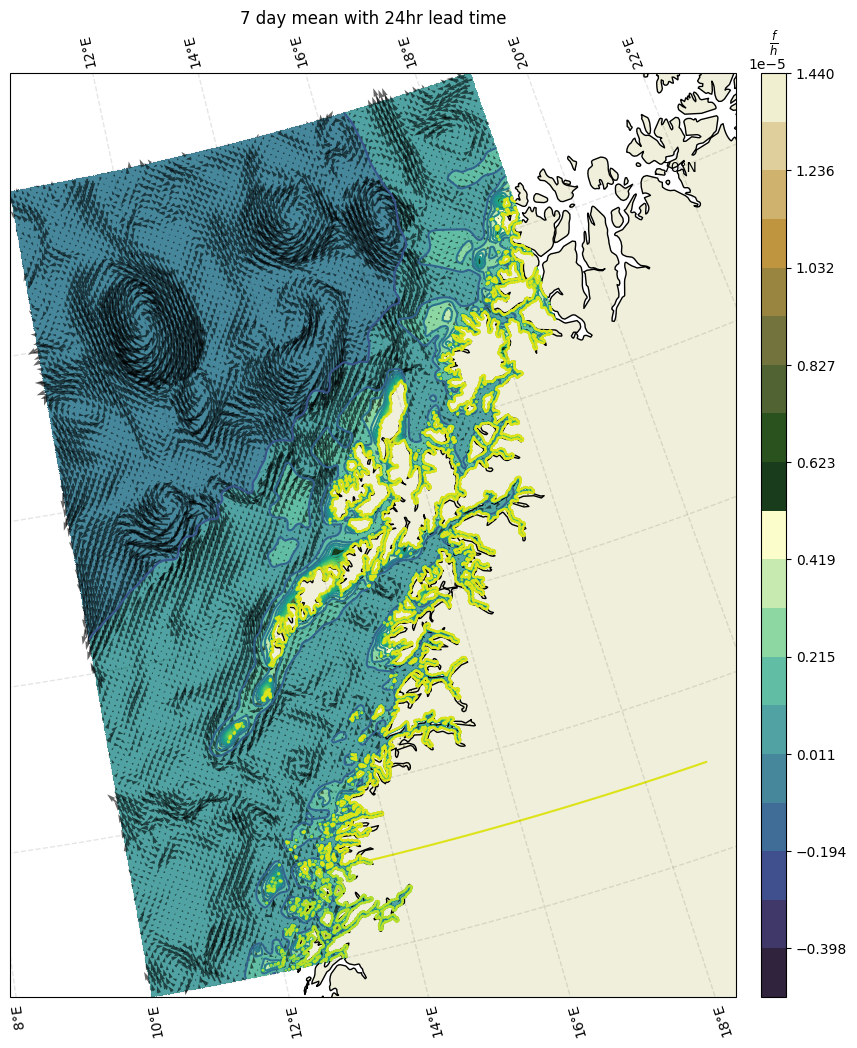

In [9]:
fh_inference(area = ds_dropped_duplicates, title = '7 day mean with 24hr lead time', compare_norkyst_area=None)